## Revisiting the LSTM

In [1]:
### importing the libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import pandas_datareader as pdr
import os
from dotenv import load_dotenv

In [2]:
### importing the key
load_dotenv('../keys.txt')
key = os.getenv('key')

### Defining the functions and working with them

In [3]:
### targeting only the features ['close', 'high', 'low' and 'open']
features_to_target = ['close', 'high', 'low', 'open']

In [4]:
### function to load the stock price
def load_stock_price(symbol, features_to_target) : 

    df = pdr.get_data_tiingo(symbol, api_key = key)
    df = df[features_to_target].reset_index(drop = True)

    return df

In [5]:
stock_boeing = load_stock_price('BA', features_to_target)
stock_boeing.tail()

,close,high,low,open
1251,231.33,235.450,229.390000,233.00
1252,230.72,231.330,227.070000,231.05
1253,224.11,230.255,221.150000,230.22
1254,229.03,229.550,224.612027,225.90
1255,227.38,231.510,227.260000,230.40


In [6]:
stock_apple = load_stock_price('AAPL', features_to_target)
stock_apple.tail()

,close,high,low,open
1251,267.61,268.36,265.07,266.090
1252,270.71,273.23,268.66,272.335
1253,270.17,271.04,267.04,267.550
1254,271.35,276.00,268.14,270.500
1255,280.14,287.22,278.37,278.855


In [7]:
### function to plot the graphs for the scaled and non scaled data as the comparison
def plot_graphs(df, df_scaled = None) : 

    if df_scaled is not None : 

        for column in df.columns : 
                
            plt.figure(figsize = (8, 4))
            plt.subplot(1, 2, 1)
            plt.title(f"Before scaling :  {column}")
            plt.plot(df[column])
            plt.subplot(1, 2, 2)
            plt.title(f"After scaling :  {column}")
            plt.plot(df_scaled[column])


    else : 
        
        for column in df.columns : 
            plt.figure(figsize = (6, 4))
            plt.title(column)
            plt.plot(df[column])

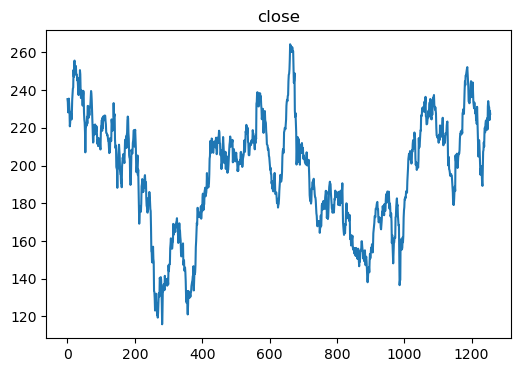

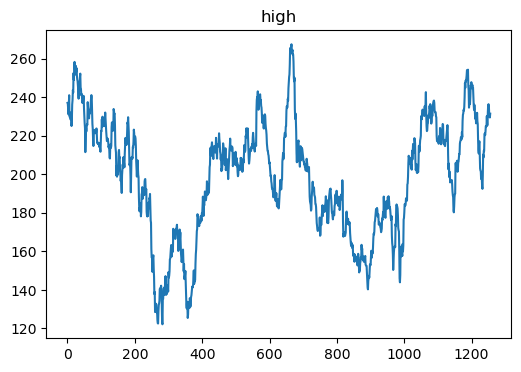

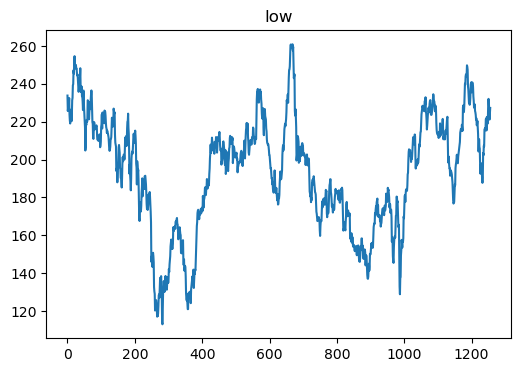

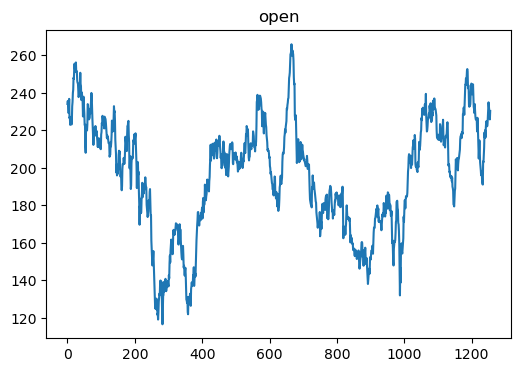

In [8]:
### plotting the graphs for the 'stock_boeing'
plot_graphs(stock_boeing)

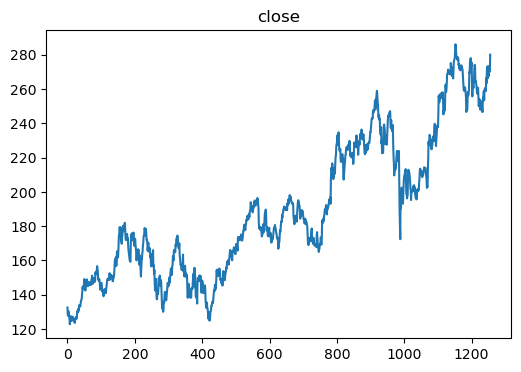

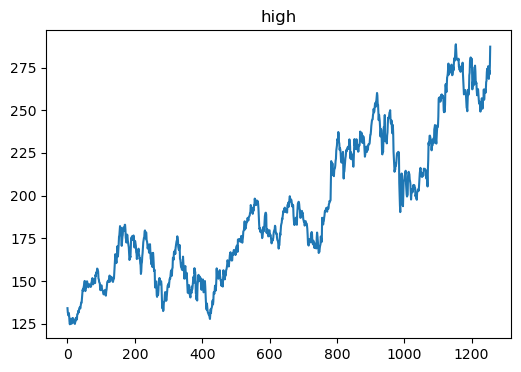

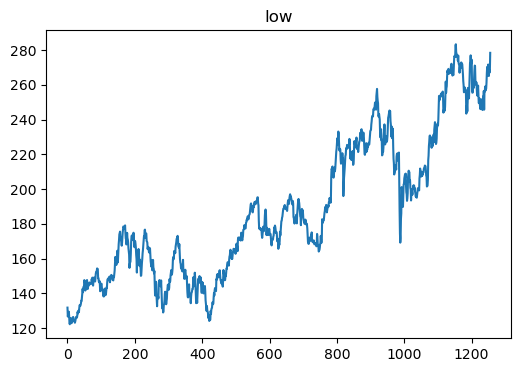

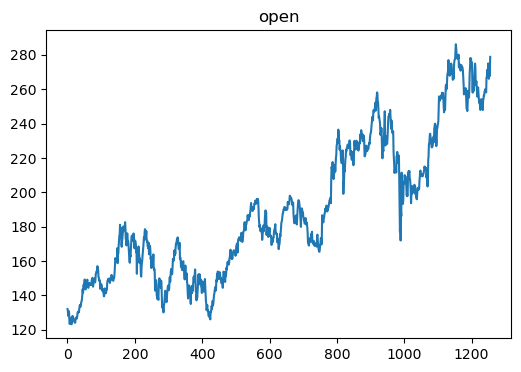

In [9]:
### plotting the graphs for the 'stock_apple'
plot_graphs(stock_apple)

In [10]:
### function to scale the data
def scale_data(df, scaler) : 

    df_scaled = scaler.fit_transform(df)
    df_scaled = pd.DataFrame(df_scaled, columns = df.columns)

    return df_scaled

In [11]:
### loading the scaler from the library
from sklearn.preprocessing import MinMaxScaler
scaler_apple = MinMaxScaler(feature_range = (0, 1))
scaler_boeing = MinMaxScaler(feature_range = (0, 1))

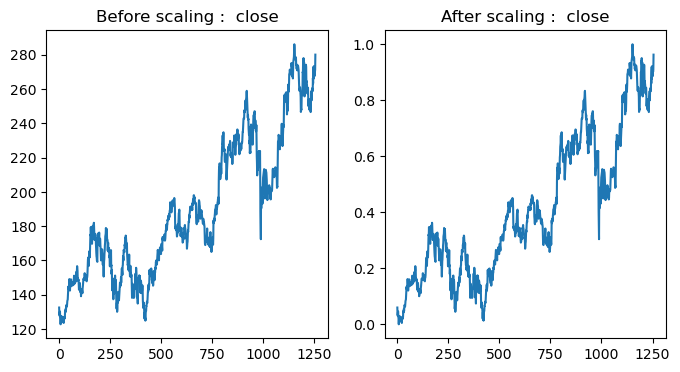

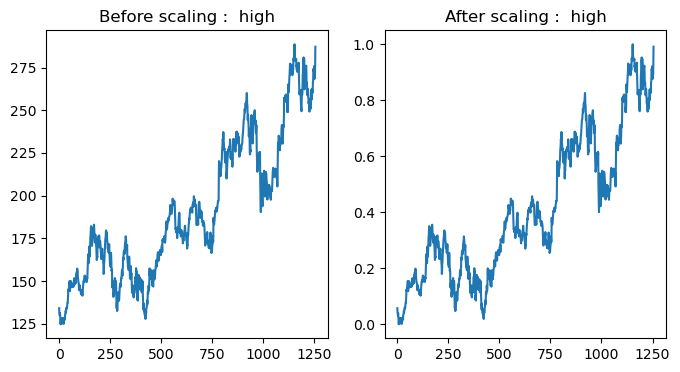

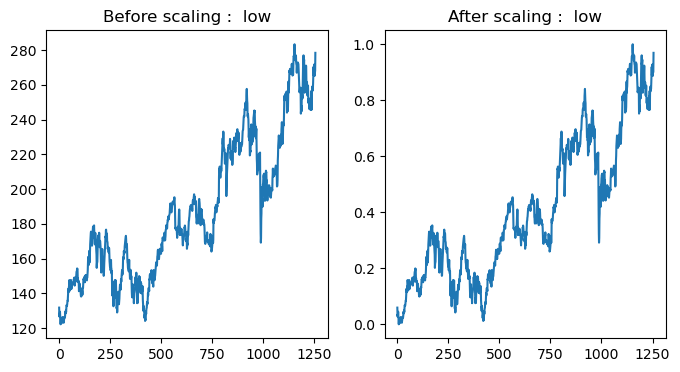

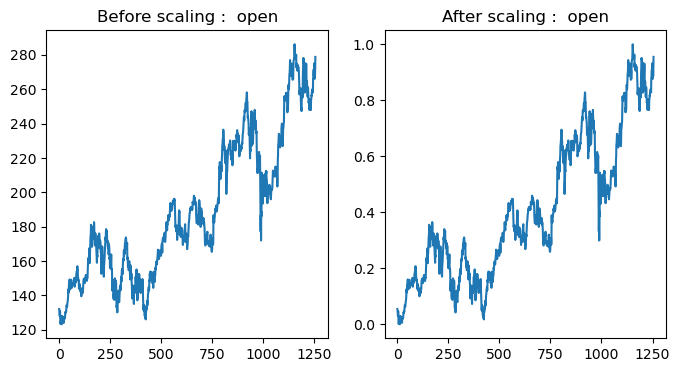

In [12]:
### scaling the data 'stock_apple' and the graphs for the comparison
stock_apple_scaled = scale_data(stock_apple, scaler = scaler_apple)
plot_graphs(stock_apple, stock_apple_scaled)

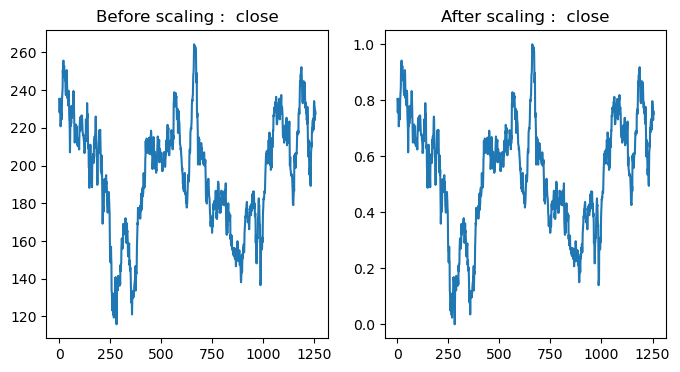

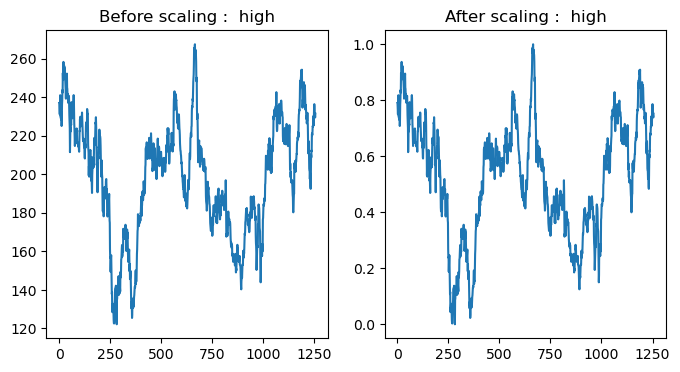

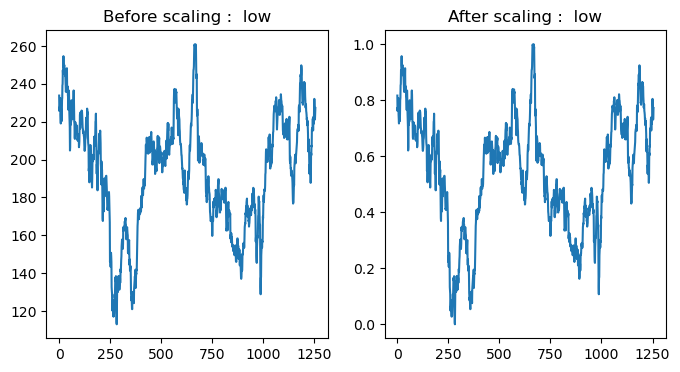

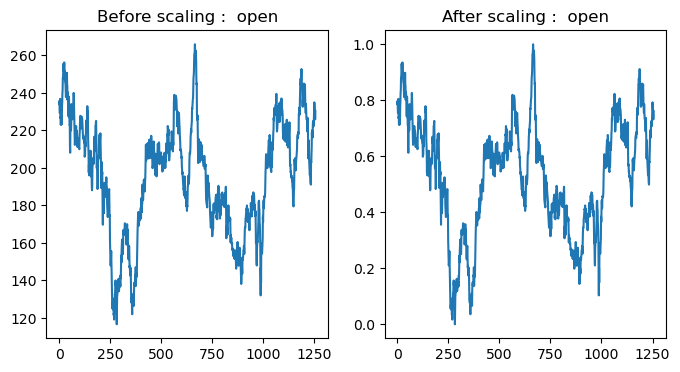

In [13]:
### scaling the data 'stock_boeing' and the graphs for the comparison
stock_boeing_scaled = scale_data(stock_boeing, scaler = scaler_boeing)
plot_graphs(stock_boeing, stock_boeing_scaled)

In [14]:
### importing the train test split library
from sklearn.model_selection import train_test_split

In [15]:
### function to create the sequences train and test sequences
def create_sequences(df, number_of_days) : 
    X, y = [], []

    for i in range(len(df) - number_of_days) : 

        X.append(df.iloc[i : i + number_of_days])
        y.append(df.iloc[i + number_of_days])

    X = np.array(X)
    y = np.array(y)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)

    print(f"{X_train.shape} :: {y_train.shape} \n{X_test.shape} :: {y_test.shape}")

    return X_train, X_test, y_train, y_test

In [16]:
### creating seuqnces for the apple stock price (90 days sequences)
X_train_apple, X_test_apple, y_train_apple, y_test_apple = create_sequences(stock_apple_scaled, number_of_days = 90)

(874, 90, 4) :: (874, 4) 
(292, 90, 4) :: (292, 4)


In [17]:
### creating seuqnces for the boeing stock price (90 days sequences)
X_train_boeing, X_test_boeing, y_train_boeing, y_test_boeing = create_sequences(stock_boeing_scaled, number_of_days = 90)

(874, 90, 4) :: (874, 4) 
(292, 90, 4) :: (292, 4)


In [18]:
### importing the libraries to create the sequeential model
import tensorflow
from tensorflow.keras.layers import Dense, Dropout, LSTM, Bidirectional
from tensorflow.keras.models import Sequential

In [20]:
### function to create the model
def create_model(days) : 

    model = Sequential([
        LSTM(100, return_sequences = True, input_shape = (days, 4)),
        Dropout(0.33),
        Bidirectional(LSTM(200)),
        Dropout(0.21),
        Dense(4, activation = 'linear')
    ])
    model.compile(optimizer = 'adam', loss = 'mean_squared_error', metrics = ['mse'])
    
    model.summary()

    return model

In [21]:
### crate the model for the 'stock_apple' 
model_apple = create_model(90)

c:\Users\lenovo\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 90, 100)        │        42,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 90, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 400)            │       481,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         1,604 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 525,204 (2.00 MB)

 Trainable params: 525,204 (2.00 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
### creating the model for the 'stock_boeing'
model_boeing = create_model(90)

c:\Users\lenovo\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 90, 100)        │        42,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 90, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 400)            │       481,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,604 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 525,204 (2.00 MB)

 Trainable params: 525,204 (2.00 MB)

 Non-trainable params: 0 (0.00 B)

### model_apple training and testing

In [23]:
### training of the 'model_apple'
model_apple.fit(X_train_apple, y_train_apple, batch_size = 32, epochs = 40, verbose = 1)

Epoch 1/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 119ms/step - loss: 0.0633 - mse: 0.0633
Epoch 2/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 122ms/step - loss: 0.0056 - mse: 0.0056
Epoch 3/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - loss: 0.0044 - mse: 0.0044
Epoch 4/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - loss: 0.0037 - mse: 0.0037
Epoch 5/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.0037 - mse: 0.0037
Epoch 6/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - loss: 0.0030 - mse: 0.0030
Epoch 7/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.0032 - mse: 0.0032
Epoch 8/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - loss: 0.0031 - mse: 0.0031
Epoch 9/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.0027 - mse: 0.0027
Epoch 10/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.0028 - mse: 0.0028
Epoch 11/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - loss: 0.0032 - mse: 0.0032
Epoch 12/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.0031 - mse: 0.0031
Epoch 13/40
28/28 ━━━━━━━

In [24]:
### predictions on the 'X_test_apple' 
y_pred_apple = model_apple.predict(X_test_apple)
y_pred_apple

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step


array([[0.8217865 , 0.8321363 , 0.82833225, 0.8147862 ],
       [0.46373257, 0.46805438, 0.4651776 , 0.45750365],
       [0.50024813, 0.509832  , 0.50129503, 0.4945767 ],
       ...,
       [0.83231556, 0.841334  , 0.8385194 , 0.8251364 ],
       [0.42444375, 0.42593434, 0.42513132, 0.41751722],
       [0.27128047, 0.2717929 , 0.26986086, 0.26265565]], dtype=float32)

In [25]:
### shape checking
y_pred_apple.shape

(292, 4)

In [26]:
### inverse scaling the both
y_pred_apple = scaler_apple.inverse_transform(y_pred_apple)
y_test_apple = scaler_apple.inverse_transform(y_test_apple)

In [27]:
### checking the y_pred_apple
y_pred_apple

array([[257.06635, 261.09372, 255.65291, 256.00275],
       [198.55318, 201.39156, 197.16685, 197.7514 ],
       [204.52054, 208.24226, 202.98357, 203.79578],
       ...,
       [258.78702, 262.60196, 257.29355, 257.69025],
       [192.1326 , 194.48471, 190.71739, 191.232  ],
       [167.10265, 169.2086 , 165.71109, 165.98337]], dtype=float32)

In [28]:
### y_test_apple
y_test_apple

array([[259.02 , 260.1  , 257.63 , 258.19 ],
       [193.6  , 195.41 , 192.97 , 195.18 ],
       [201.7  , 202.13 , 200.12 , 200.28 ],
       ...,
       [254.04 , 258.   , 253.14 , 257.805],
       [188.08 , 189.3  , 186.6  , 189.16 ],
       [174.61 , 174.84 , 172.31 , 174.01 ]])

In [29]:
### functions to plot the metrices and the graphs to check the model's performances
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
def metrices_and_graphs(y_test, y_pred) : 

    print(f"mean_absolute_error : {mean_absolute_error(y_test, y_pred)}")
    print(f"root_mean_squared_error : {root_mean_squared_error(y_test, y_pred)}")
    print(f"mean_squared_error : {mean_squared_error(y_test, y_pred)}")

    plt.figure(figsize = (12, 4))

    #----------Plot to see the trend made by model
    plt.subplot(1, 3, 1)
    plt.plot(y_pred, label = 'Predicted')
    plt.plot(y_test, label = 'Actual')

    #----------Actual vs Predicted points
    plt.subplot(1, 3, 2)
    plt.plot(y_test, label='Actual', color='blue', marker='o')
    plt.plot(y_pred, label='Predicted', color='red', marker='x')
    plt.xlabel('Index')
    plt.ylabel('Target Value')
    plt.legend()
    plt.grid(True)

    #--------- Best fit line
    plt.subplot(1, 3, 3)
    plt.scatter(y_test, y_pred, color = 'blue', alpha = 0.5, label = 'Predicted')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             color = 'red', linewidth = 2, label = 'Best fit line')
    plt.xlabel('Actual Values (y_test)')
    plt.ylabel('Predicted Values (y_pred)')
    plt.legend()
    plt.grid(True)
    plt.show()

mean_absolute_error : 4.120066662095999
root_mean_squared_error : 5.548377227805196
mean_squared_error : 30.78448986202728


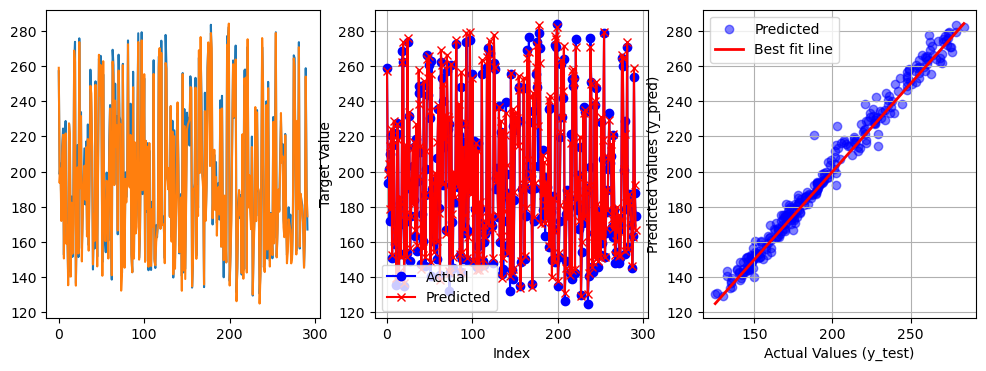

mean_absolute_error : 4.453007629310921
root_mean_squared_error : 5.75635033284507
mean_squared_error : 33.13556915444555


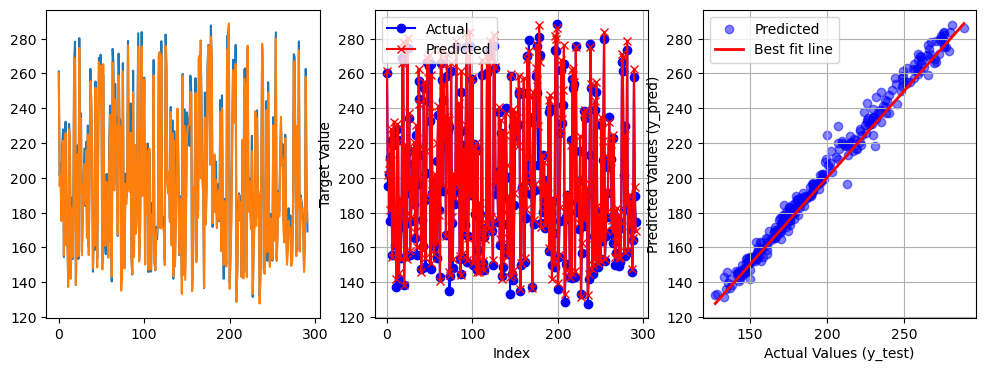

mean_absolute_error : 4.004093702467827
root_mean_squared_error : 5.555876771745149
mean_squared_error : 30.867766702817303


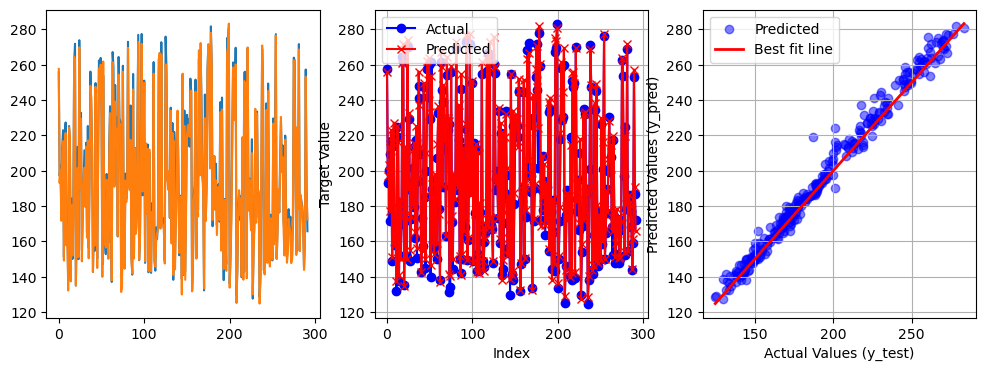

mean_absolute_error : 3.09835634330854
root_mean_squared_error : 4.486022464073266
mean_squared_error : 20.12439754816998


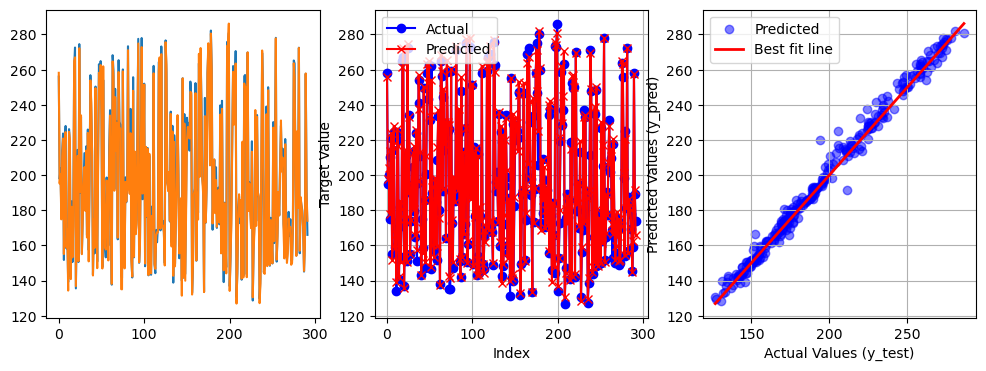

In [35]:
### checking the metrices and graphs
for i in range(0, 4) : 
    metrices_and_graphs(y_test_apple[:, i], y_pred_apple[:, i])

### model_boeing training and testing

In [36]:
### training the model
model_boeing.fit(X_train_boeing, y_train_boeing, batch_size = 32, epochs = 40, verbose = 1)

Epoch 1/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - loss: 0.0770 - mse: 0.0770
Epoch 2/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - loss: 0.0072 - mse: 0.0072
Epoch 3/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - loss: 0.0068 - mse: 0.0068
Epoch 4/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.0061 - mse: 0.0061
Epoch 5/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - loss: 0.0053 - mse: 0.0053
Epoch 6/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.0049 - mse: 0.0049
Epoch 7/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.0048 - mse: 0.0048
Epoch 8/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - loss: 0.0042 - mse: 0.0042
Epoch 9/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - loss: 0.0041 - mse: 0.0041
Epoch 10/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.0044 - mse: 0.0044
Epoch 11/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.0033 - mse: 0.0033
Epoch 12/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - loss: 0.0032 - mse: 0.0032
Epoch 13/40
28/28 ━━━━━━━

In [37]:
### predicting the y_pred_boeing
y_pred_boeing = model_boeing.predict(X_test_boeing)
y_train_boeing

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step


array([[0.5557577 , 0.52872377, 0.56626995, 0.5454789 ],
       [0.58884172, 0.56415549, 0.58878821, 0.57836571],
       [0.59524291, 0.56835225, 0.53753043, 0.55726725],
       ...,
       [0.23320531, 0.24630203, 0.24364349, 0.26148694],
       [0.6277205 , 0.624699  , 0.64376522, 0.64199598],
       [0.65662691, 0.63357413, 0.64153368, 0.62525117]])

In [38]:
### inverse scaling the datasets
y_pred_boeing = scaler_boeing.inverse_transform(y_pred_boeing)
y_test_boeing = scaler_boeing.inverse_transform(y_test_boeing)

mean_absolute_error : 4.525194769036281
root_mean_squared_error : 5.837326377147885
mean_squared_error : 34.074379233346455


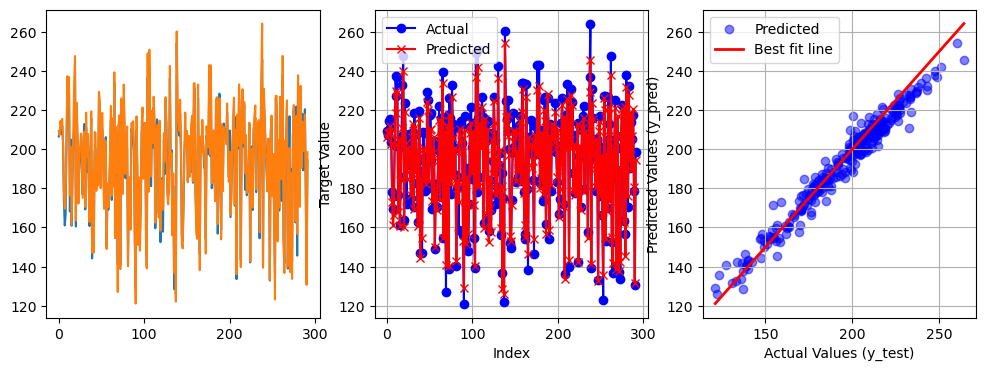

mean_absolute_error : 4.033961229883482
root_mean_squared_error : 5.285757053847155
mean_squared_error : 27.939227632294962


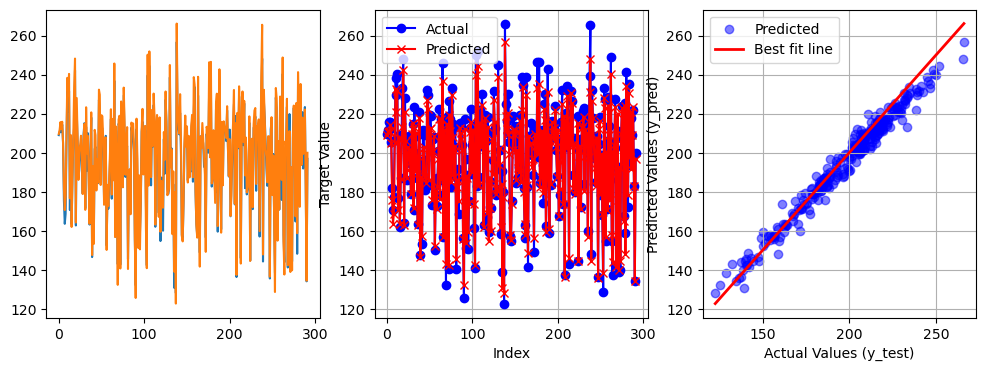

mean_absolute_error : 3.5517668268491134
root_mean_squared_error : 4.718388254104015
mean_squared_error : 22.263187716466735


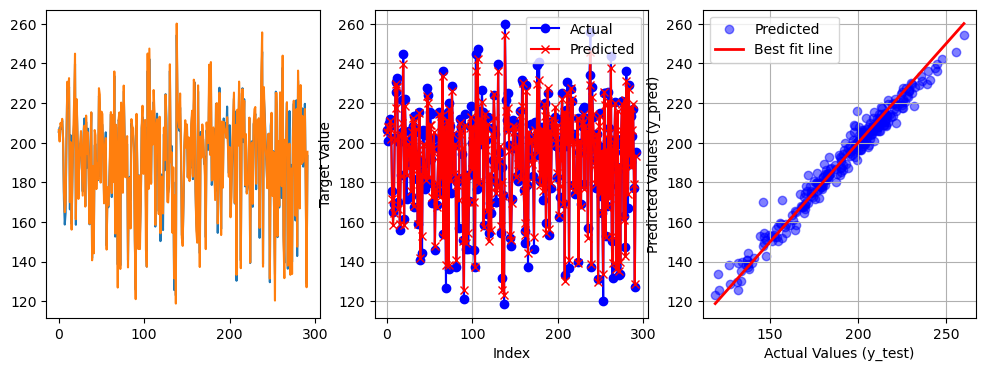

mean_absolute_error : 3.703346225477244
root_mean_squared_error : 4.538660819069317
mean_squared_error : 20.599442030554968


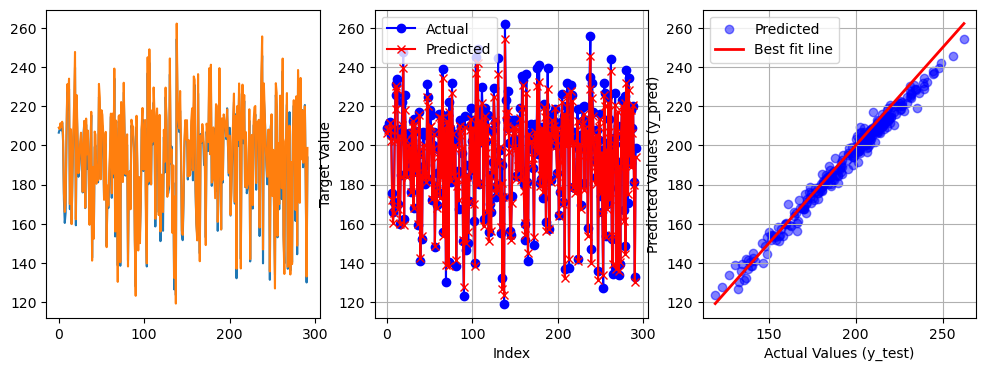

In [39]:
### checking the metrics and the graphs
for i in range(0, 4) : 
    metrices_and_graphs(y_test_boeing[:, i], y_pred_boeing[:, i])

### new predictions

In [40]:
### will work tomorrow